# データの読み込み

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DataSample.xlsx の読み込み
df = pd.read_excel('/content/drive/My Drive/Colab Notebooks/DataSample.xlsx')
df

,ID,Gender,GPA,Attendance,Japanese,English,Mathematics,Prefecture
0,1,M,1.355,0.58,64.0,7.0,35.0,長崎県
1,2,F,1.847,0.65,NaN,NaN,NaN,福岡県
2,3,M,3.261,0.96,62.0,63.0,30.0,福岡県
3,4,M,2.320,0.93,58.0,56.0,45.0,福岡県
4,5,F,0.000,0.30,70.0,26.0,40.0,福岡県
...,...,...,...,...,...,...,...,...
516,517,M,2.419,0.83,70.0,85.0,NaN,熊本県
517,518,M,1.716,0.84,62.0,12.0,NaN,福岡県
518,519,M,1.629,0.88,42.0,16.0,NaN,福岡県
519,520,M,1.490,0.78,56.0,NaN,NaN,福岡県


In [ ]:
# ID のデータ型を数値から文字列に変換
df['ID'] =  df['ID'].astype(str)

In [ ]:
# 基本統計量を表示
df.describe()

,GPA,Attendance,Japanese,English,Mathematics
count,521.000000,521.000000,495.000000,493.000000,217.000000
mean,1.977735,0.805451,55.557576,38.880325,39.451613
std,0.766971,0.129656,13.800495,25.320544,21.797866
min,0.000000,0.200000,19.000000,0.000000,0.000000
25%,1.400000,0.730000,46.000000,19.000000,20.000000
50%,1.909000,0.830000,56.000000,37.000000,40.000000
75%,2.471000,0.900000,66.000000,57.000000,55.000000
max,3.786000,0.990000,88.000000,98.000000,100.000000


In [ ]:
# 欠損値の確認
df.isnull().sum()


ID               0
Gender           0
GPA              0
Attendance       0
Japanese        26
English         28
Mathematics    304
Prefecture       0
dtype: int64

In [ ]:
# 欠損値を含む行を削除
df = df.dropna(how='any')
# 状態の確認
print(df.shape)
df.isnull().sum()

(216, 8)


ID             0
Gender         0
GPA            0
Attendance     0
Japanese       0
English        0
Mathematics    0
Prefecture     0
dtype: int64

# データの視覚化


In [ ]:
# Warning を非表示に設定
import warnings
warnings.resetwarnings()
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', RuntimeWarning)

##  ライブラリ matplotlib の利用

### histgram

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fd5b1fc7da0>,
      dtype=object)

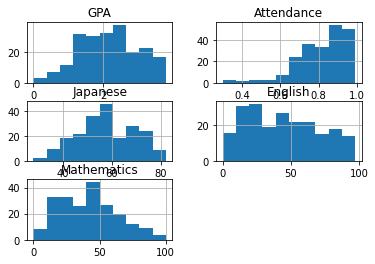

In [ ]:
# pandas > matplotlib でヒストグラムの一括表示
df.hist( )

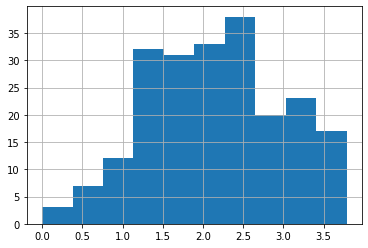

In [ ]:
# pandas > matplotlib で GPA のヒストグラムの表示
df["GPA"] .hist( )

### plot.scatter

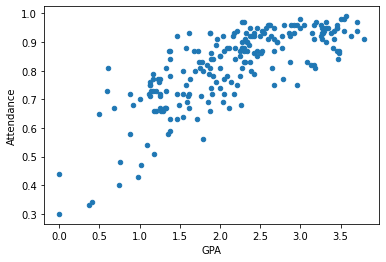

In [ ]:
# pandas > matplotlib で GPA と Attendance の相関を散布図で確認
df.plot.scatter(x='GPA', y='Attendance')

### boxplot


/usr/local/lib/python3.6/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


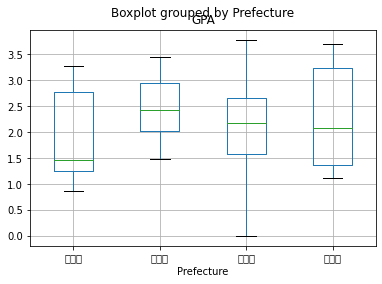

In [ ]:
# pandas > matplotlib で 県別のGPAの分布を比較
df.boxplot( column="GPA", by="Prefecture")

### plot.bar

In [ ]:
# 棒グラフ用 性別ごとに各平均値を算出
df_mean = df.groupby("Gender", as_index=False).mean()
df_mean

,Gender,GPA,Attendance,Japanese,English,Mathematics
0,F,2.617825,0.849500,62.350000,58.475000,39.800000
1,M,2.043102,0.806193,56.420455,41.142045,39.539773


In [ ]:
# 性別・国語・英語・数学の平均点のみのデータテーブルをつくる
df_mean = df_mean.loc[ : , ["Gender" , "Japanese" , "English" , "Mathematics" ]]
df_mean.set_index("Gender")


,Japanese,English,Mathematics
Gender,,,
F,62.350000,58.475000,39.800000
M,56.420455,41.142045,39.539773


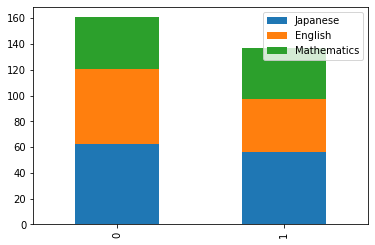

In [ ]:
# 縦棒グラフを描画
df_mean.plot.bar(stacked=True)

In [ ]:
# 100%積み上げ縦棒グラフ用 クロス集計データの作成
df_cross = pd.crosstab( index=df["Gender"] , columns=df["Prefecture"], normalize="index")
df_cross

Prefecture,佐賀県,熊本県,福岡県,長崎県
Gender,,,,
F,0.025000,0.075000,0.850000,0.050000
M,0.056818,0.039773,0.823864,0.079545


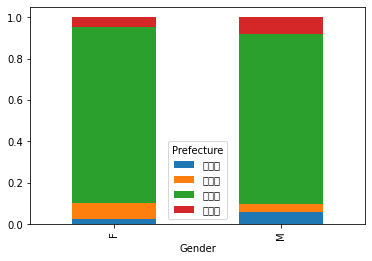

In [ ]:
df_cross.plot.bar(stacked=True)

## ライブラリ seaborn の利用
* 量的変数の分布 ＞ distplot 関数
* 質的変数の度数分布 ＞ countplot 関数

### distplot

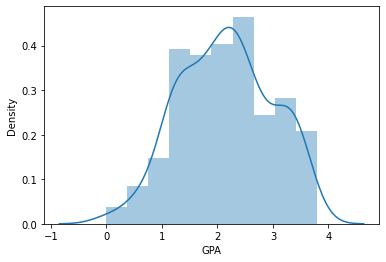

In [ ]:
# seaborn のdistplot  関数でヒストグラムを描画
sns.distplot( df["GPA"] )

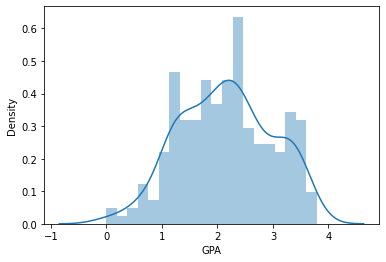

In [ ]:
# seaborn のdistplot  関数でヒストグラムを描画（bins を増やして区切りを細かく）
sns.distplot( df["GPA"] , bins=20 )

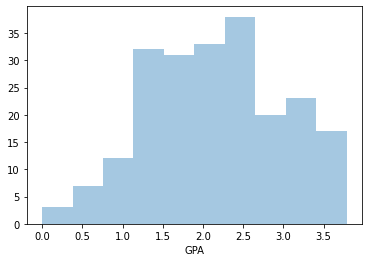

In [ ]:
# seaborn の distplot  関数でヒストグラムを描画（カーネル密度関数をOFF）
sns.distplot( df["GPA"] , kde=False )

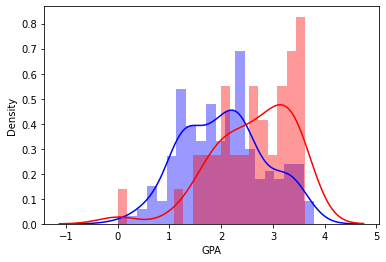

In [ ]:
# seaborn の distplot  関数で２つのヒストグラムを表示する
df_m = df[ df["Gender"] == "M" ]
df_f = df[ df["Gender"] == "F" ]
sns.distplot(df_m["GPA"] , bins=20, color ="b" )
sns.distplot(df_f["GPA"] , bins=20, color ="r" )

### countplot

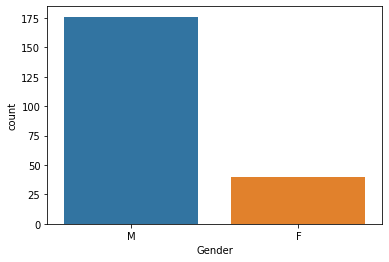

In [ ]:
#  seaborn の countplot  関数で度数を表示
sns.countplot( x="Gender", data = df )

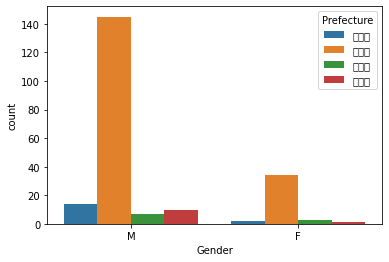

In [ ]:
#  seaborn の countplot  関数で、色分け表示
sns.countplot( x="Gender", hue="Prefecture", data = df )

### boxplot

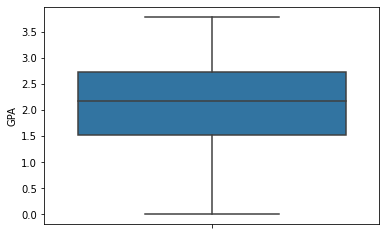

In [ ]:
#  seaborn の boxplot  関数で、ボックスプロット
sns.boxplot( y ="GPA", data =df )

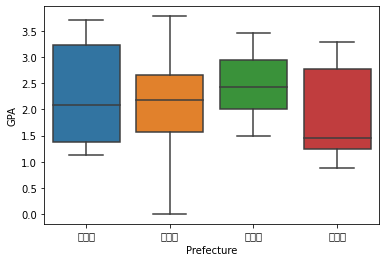

In [ ]:
#  seaborn の boxplot  関数で、複数のデータを比較
sns.boxplot( x = "Prefecture", y = "GPA", data =df )

### scatterplot

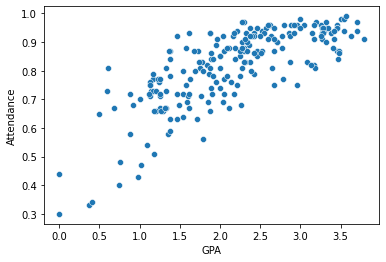

In [ ]:
#  seaborn の scatterplot 関数で散布図を作成
sns.scatterplot ( x = "GPA", y = "Attendance", data =df )

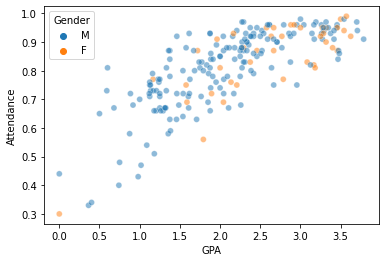

In [ ]:
#  seaborn の scatterplot 関数で質的変数を色分け表示
sns.scatterplot ( x = "GPA", y = "Attendance", hue  = "Gender", alpha = 0.5, data =df )

### pairplot

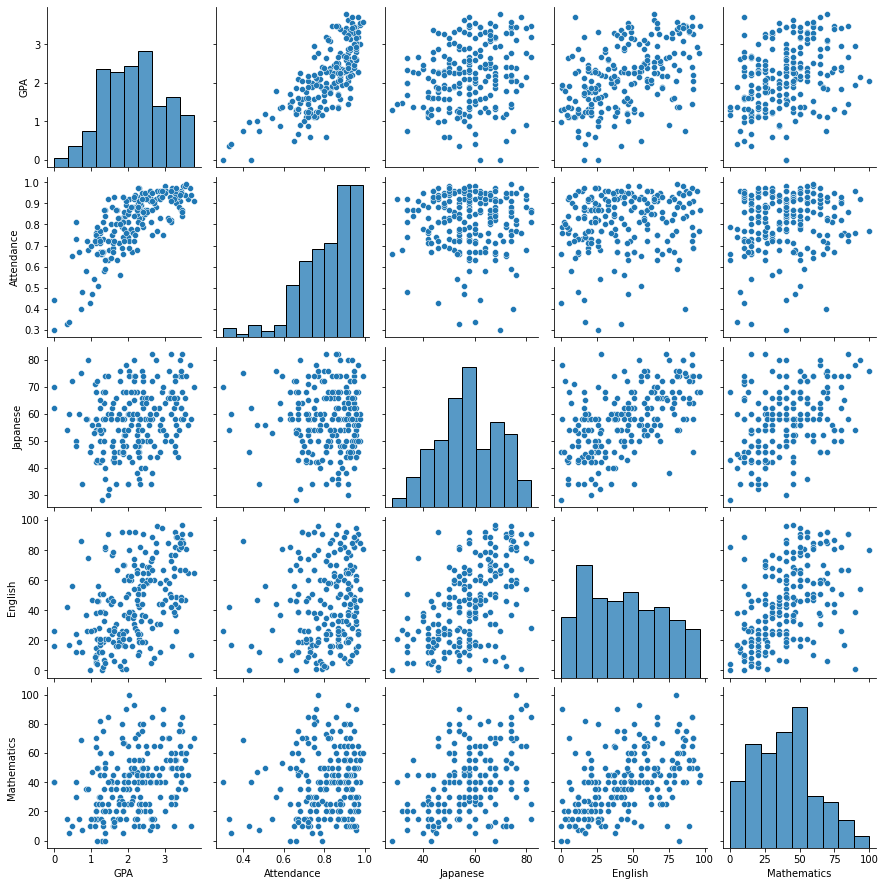

In [ ]:
#  seaborn の 散布図行列（ペアプロット）
sns.pairplot ( data =df )

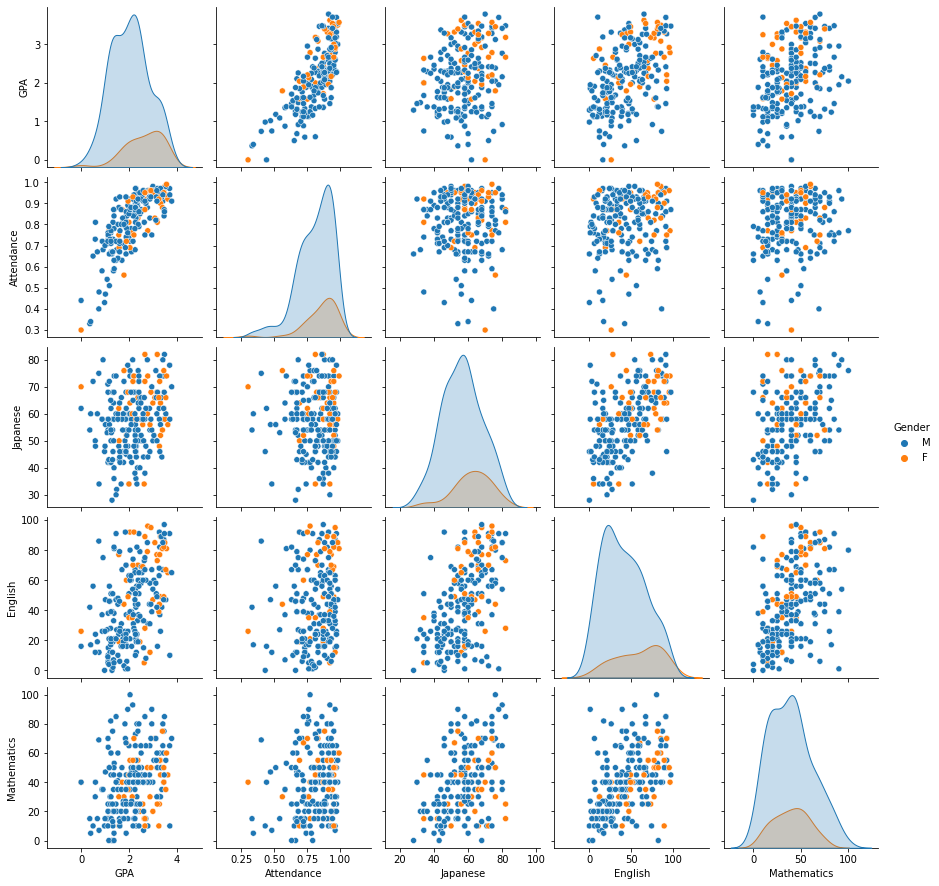

In [ ]:
#  seaborn の 散布図行列（ペアプロット）色分け
sns.pairplot ( hue ="Gender", data =df )

### barplot


In [ ]:
# 棒グラフ用 性別ごとに各平均値を算出
df_mean = df.groupby("Gender", as_index=False).mean()
df_mean

,Gender,GPA,Attendance,Japanese,English,Mathematics
0,F,2.617825,0.849500,62.350000,58.475000,39.800000
1,M,2.043102,0.806193,56.420455,41.142045,39.539773


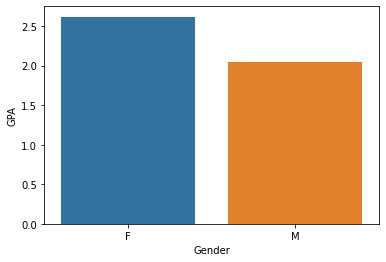

In [ ]:
# 縦棒グラフを描画
sns.barplot( x="Gender", y="GPA", data=df_mean)

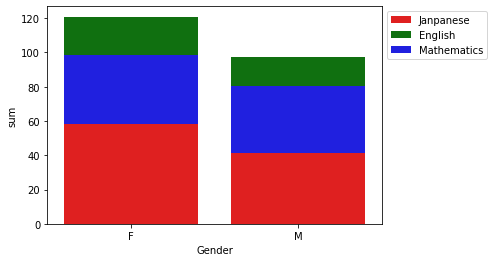

In [ ]:
# 積み上げ縦棒グラフ（３種類：国語・英語・数学）
f, ax = plt.subplots()
sns.barplot( x="Gender", y="Japanese", data=df_mean, color="red", label="Janpanese" )
sns.barplot( x="Gender", y="English", data=df_mean, color="green", label="English", bottom= df_mean["Japanese"] )
sns.barplot( x="Gender", y="Mathematics", data=df_mean, color="blue", label="Mathematics", bottom= df_mean["English"] )
plt.ylabel("sum")
ax.legend(loc ="upper left", bbox_to_anchor = (1,1) )

In [ ]:
# 100%積み上げ縦棒グラフ用 クロス集計データの作成
df_cross = pd.crosstab( index=df["Gender"] , columns=df["Prefecture"], normalize="index")
df_cross

Prefecture,佐賀県,熊本県,福岡県,長崎県
Gender,,,,
F,0.025000,0.075000,0.850000,0.050000
M,0.056818,0.039773,0.823864,0.079545


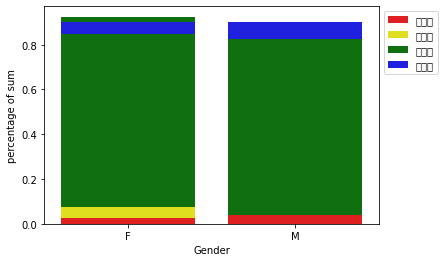

In [ ]:
# 100%積み上げ縦棒グラフ
f, ax = plt.subplots()
sns.barplot( x=df_cross.index, y=df_cross[ "佐賀県" ] , color="red", label="佐賀県" )
sns.barplot( x=df_cross.index,  y=df_cross[ "熊本県" ] , color="yellow", label="熊本県", bottom= df_cross["佐賀県"] )
sns.barplot( x=df_cross.index, y=df_cross[ "福岡県" ] , color="green", label="福岡県", bottom= df_cross["熊本県"] )
sns.barplot( x=df_cross.index,  y=df_cross[ "長崎県" ] , color="blue", label="長崎県", bottom= df_cross["福岡県"] )
plt.ylabel( "percentage of sum" )
ax.legend( loc ="upper left", bbox_to_anchor = (1,1) )